In [1]:
import warnings
from pathlib import Path

import echopype as ep  # we recommend using "ep"
import xarray as xr
import hvplot.xarray  # for interactive plots

import matplotlib.pyplot as plt

In [2]:
raw_path = './depth_test/L0384-D20170810-T182653-ES60.raw'

In [3]:
ed = ep.open_raw(raw_path, sonar_model='EK60')

In [4]:
ed

<EchoData: standardized raw data from Internal Memory>
Top-level: contains metadata about the SONAR-netCDF4 file format.
├── Environment: contains information relevant to acoustic propagation through water.
├── Platform: contains information about the platform on which the sonar is installed.
│   └── NMEA: contains information specific to the NMEA protocol.
├── Provenance: contains metadata about how the SONAR-netCDF4 version of the data were obtained.
├── Sonar: contains sonar system metadata and sonar beam groups.
│   └── Beam_group1: contains backscatter power (uncalibrated) and other beam or channel-specific data, including split-beam angle data when they exist.
└── Vendor_specific: contains vendor-specific information about the sonar and the data.

In [25]:
# We can then proceed to compute Sv from the raw data. Here, we
# use the calibration and environmental parameters already stored
# in the original instrument-generated .raw file.
#
# Echopype also supports updating these parameters as part of the
# function call, or using an Echoview .ECS file. Note that this
# functionality is in beta and may not cover all equivalent
# vocabulary recognized by Echoview.
#
# compute_Sv requires two arguments: waveform_mode and
# encode_mode, because EK80 files can contain data from a variety
# of sampling configurations, including:

# Use the correct waveform_mode and encode_mode combination
#ds_Sv = ep.calibrate.compute_Sv(ed, waveform_mode="CW", encode_mode="power")
ds_Sv = ep.calibrate.compute_Sv(ed)

# depth_offset=0 for transducer
ds_Sv = ep.consolidate.add_depth(ds_Sv, ed, depth_offset=0)

ds_Sv = ep.consolidate.add_location(ds_Sv, ed)

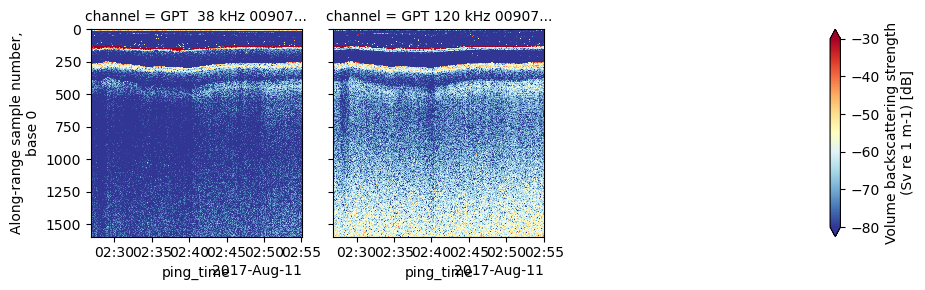

In [26]:
ds_Sv["Sv"].plot(
    x="ping_time", 
    row="channel", col_wrap=3,
    vmin=-80, vmax=-30,
    cmap="RdYlBu_r", yincrease=False
)

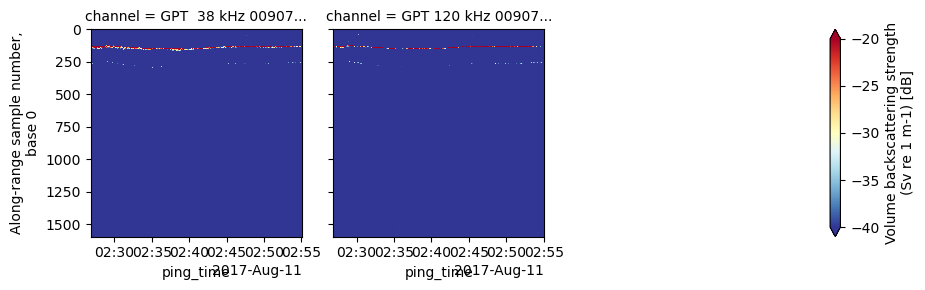

In [7]:
# Adjust the colourbar range to highlight the seafloor.
ds_Sv["Sv"].plot(
    x="ping_time", 
    row="channel", col_wrap=3,
    vmin=-40, vmax=-20,
    cmap="RdYlBu_r", yincrease=False
)

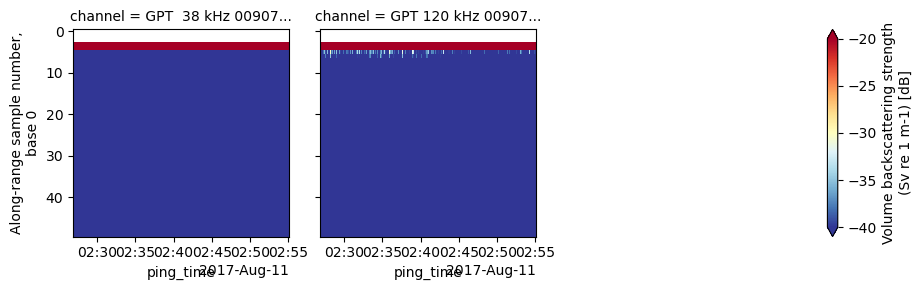

In [8]:
#We show the 200 first samples, to observe the surface saturation zone.
# (We need to skip them to use the basic seafloor detection.)

ds_Sv.isel(range_sample=slice(0, 50))["Sv"].plot(
    x="ping_time", 
    row="channel", 
    col_wrap=3,
    vmin=-40, vmax=-20,
    cmap="RdYlBu_r", 
    yincrease=False
)

In [9]:
# We use the basic bottom detection function from the seafloor_detection submodule
# within the echopype.mask package. We use here the 70 kHz channel to detect the seafloor.
sel_channel = "GPT  38 kHz 009072067bdf 1 ES38B"

from echopype.mask import detect_seafloor
import xarray as xr

# Call detect_seafloor dispatcher
basic_depth = detect_seafloor(
    ds_Sv,
    method="basic",
    params={
        "var_name": "Sv",
        "channel": sel_channel,
        "threshold": (-40, -20),
        "offset_m": 0.3,
        "bin_skip_from_surface": 50, # due to surface saturation
    },
)

# Check output
assert isinstance(basic_depth, xr.DataArray)
assert set(basic_depth.dims) == {"ping_time"}
basic_depth

<xarray.DataArray 'bottom_depth' (ping_time: 4009)> Size: 32kB
array([25.28975994, 24.16079994, 23.97263994, ..., 23.59631994,
       23.59631994, 23.40815994], shape=(4009,))
Coordinates:
  * ping_time  (ping_time) datetime64[ns] 32kB 2017-08-11T02:26:53.016951 ......
Attributes:
    detector:               basic
    threshold_min:          -40.0
    threshold_max:          -20.0
    offset_m:               0.3
    bin_skip_from_surface:  50
    channel:                GPT  38 kHz 009072067bdf 1 ES38B

In [10]:
print(type(basic_depth)) # should be xarray.DataArray
basic_depth.coords

<class 'xarray.core.dataarray.DataArray'>


Coordinates:
  * ping_time  (ping_time) datetime64[ns] 32kB 2017-08-11T02:26:53.016951 ......

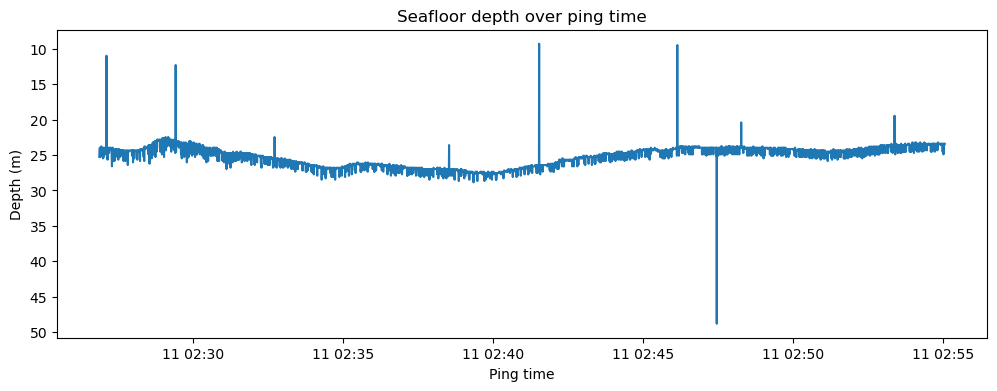

In [11]:
#We plot the seafloor. The bottom is computed because we access it.

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(basic_depth["ping_time"].values, basic_depth.values, fillstyle='full', markersize=1)

ax.set_title("Seafloor depth over ping time")
ax.set_xlabel("Ping time")
ax.set_ylabel("Depth (m)")
ax.invert_yaxis()
plt.show()

In [12]:
# We compare the results with the Blackwell method, which requires
# the angle_alongship and angle_athwartship variables.

# Extract from EchoData
angle_along = ed["Sonar/Beam_group1"]["angle_alongship"]
angle_athwart = ed["Sonar/Beam_group1"]["angle_athwartship"]

# Merge into ds_Sv
ds_Sv = ds_Sv.assign(
    angle_alongship=angle_along,
    angle_athwartship=angle_athwart
)

required_vars = ["Sv", "angle_alongship", "angle_athwartship", "depth"]
missing = [var for var in required_vars if var not in ds_Sv]
if not missing:
    print("All required variables are present for Blackwell detection.")
else:
    print(f"Missing required variables: {missing}.")

All required variables are present for Blackwell detection.


In [13]:
angle_along

<xarray.DataArray 'angle_alongship' (channel: 2, ping_time: 4009,
                                     range_sample: 1594)> Size: 13MB
array([[[   0,   -1,   -1, ...,   32,   24,   69],
        [   0,   -1,   -1, ..., -110,  -92,  121],
        [   0,   -1,   -1, ...,  -44,   40, -128],
        ...,
        [   0,   -1,   -1, ...,  -80,   -2,  -89],
        [   0,   -1,   -1, ...,  -16,   84,  123],
        [   0,   -1,   -1, ...,  -16,    7,   29]],

       [[   1,    2,    2, ...,  112, -116,  117],
        [   1,    2,    2, ...,    4, -107,   88],
        [   1,    2,    2, ...,  -99,  -24,  -97],
        ...,
        [   1,    2,    2, ...,  -22,   85,  124],
        [   1,    2,    2, ...,   88,   86,    2],
        [   1,    2,    2, ...,   62,   91,  -50]]],
      shape=(2, 4009, 1594), dtype=int8)
Coordinates:
  * channel       (channel) <U35 280B 'GPT  38 kHz 009072067bdf 1 ES38B' 'GPT...
  * ping_time     (ping_time) datetime64[ns] 32kB 2017-08-11T02:26:53.016951 ...
  * range_sample  (range_sample) int64 13kB 0 1 2 3 4 ... 1590 1591 1592 1593
Attributes:
    long_name:  electrical alongship angle
    comment:    Introduced in echopype for Simrad echosounders. The alongship...

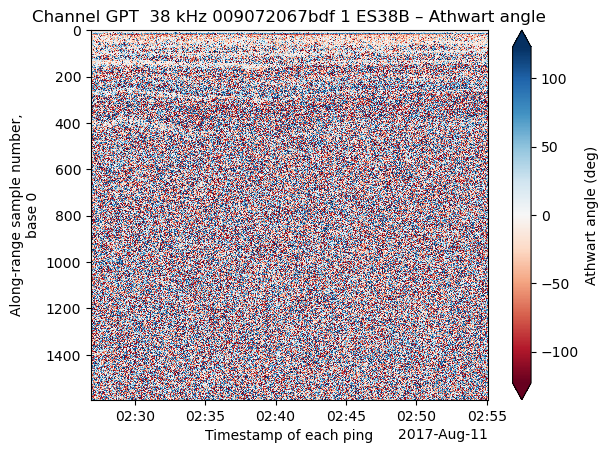

In [14]:
import matplotlib.pyplot as plt

# Select one channel
angle_athwart_sel = angle_athwart.sel(channel=sel_channel)

angle_athwart_sel.plot(
    x="ping_time",
    y="range_sample",
    cmap="RdBu",
    yincrease=False,
    robust=True,
    cbar_kwargs={"label": "Athwart angle (deg)"}
)
plt.title(f"Channel {sel_channel} – Athwart angle")
plt.show()

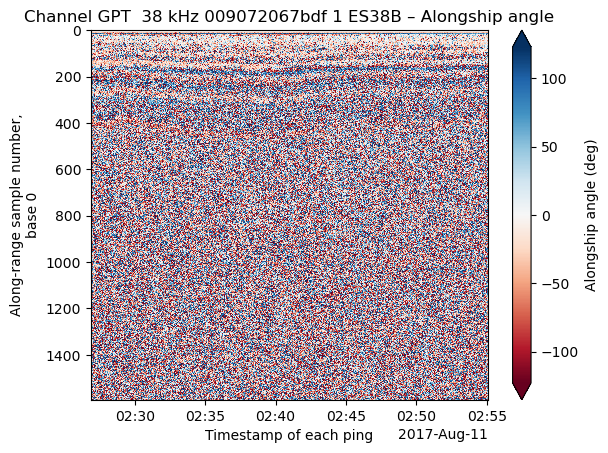

In [15]:
angle_along_sel = angle_along.sel(channel=sel_channel)

angle_along_sel.plot(
    x="ping_time",
    y="range_sample",
    cmap="RdBu",
    yincrease=False,
    robust=True,
    cbar_kwargs={"label": "Alongship angle (deg)"}
)
plt.title(f"Channel {sel_channel} – Alongship angle")
plt.show()

In [16]:
blackwell_depth = detect_seafloor(
    ds=ds_Sv,
    method="blackwell",
    params={
        "channel": sel_channel,
        "var_name": "Sv",
        "threshold": [-40, 702, 282],
        "offset": 0.3,
        "r0": 10,
        "r1": 1000,
        "wtheta": 28,
        "wphi": 52,
    }
)

In [17]:
# Check output
assert isinstance(blackwell_depth, xr.DataArray)
assert set(blackwell_depth.dims) == {"ping_time"}
blackwell_depth

<xarray.DataArray 'bottom_depth' (ping_time: 4009)> Size: 32kB
array([23.97263994, 24.16079994, 23.97263994, ..., 23.59631994,
       23.59631994, 23.40815994], shape=(4009,))
Coordinates:
  * ping_time  (ping_time) datetime64[ns] 32kB 2017-08-11T02:26:53.016951 ......
Attributes:
    detector:               blackwell
    threshold_Sv:           -40.0
    threshold_angle_major:  702.0
    threshold_angle_minor:  282.0
    offset_m:               0.3
    channel:                GPT  38 kHz 009072067bdf 1 ES38B

In [18]:
# We compare the results from both seafloor detection methods.

# Get the ping_time values from each DataArray
pt_basic = basic_depth.ping_time
pt_blackwell = blackwell_depth.ping_time

# Find ping times in basic_depth but not in blackwell_depth
missing_in_blackwell = pt_basic[~pt_basic.isin(pt_blackwell)]
print(f"Ping times in basic_depth but missing in blackwell_depth: {missing_in_blackwell.size}")
print(missing_in_blackwell.values)

# Find ping times in blackwell_depth but not in basic_depth
missing_in_basic = pt_blackwell[~pt_blackwell.isin(pt_basic)]
print(f"Ping times in blackwell_depth but missing in basic_depth: {missing_in_basic.size}")
print(missing_in_basic.values)

Ping times in basic_depth but missing in blackwell_depth: 0
[]
Ping times in blackwell_depth but missing in basic_depth: 0
[]


In [19]:
print("bd.ping_time:", basic_depth)#.ping_time)
print("\n\n")
print("bw.ping_time:", blackwell_depth)#.ping_time)


bd.ping_time: <xarray.DataArray 'bottom_depth' (ping_time: 4009)> Size: 32kB
array([25.28975994, 24.16079994, 23.97263994, ..., 23.59631994,
       23.59631994, 23.40815994], shape=(4009,))
Coordinates:
  * ping_time  (ping_time) datetime64[ns] 32kB 2017-08-11T02:26:53.016951 ......
Attributes:
    detector:               basic
    threshold_min:          -40.0
    threshold_max:          -20.0
    offset_m:               0.3
    bin_skip_from_surface:  50
    channel:                GPT  38 kHz 009072067bdf 1 ES38B



bw.ping_time: <xarray.DataArray 'bottom_depth' (ping_time: 4009)> Size: 32kB
array([23.97263994, 24.16079994, 23.97263994, ..., 23.59631994,
       23.59631994, 23.40815994], shape=(4009,))
Coordinates:
  * ping_time  (ping_time) datetime64[ns] 32kB 2017-08-11T02:26:53.016951 ......
Attributes:
    detector:               blackwell
    threshold_Sv:           -40.0
    threshold_angle_major:  702.0
    threshold_angle_minor:  282.0
    offset_m:               0.3
    cha

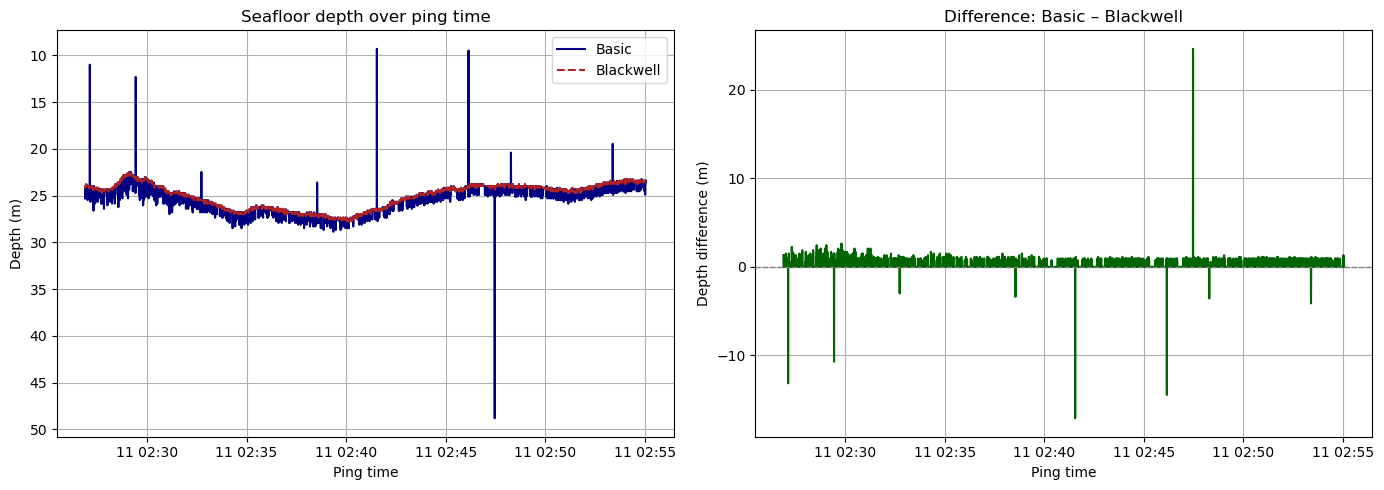

In [20]:
# Align both bottom detections on ping_time using xarray
bd, bw = xr.align(basic_depth, blackwell_depth, join="inner")
assert bd.ping_time.equals(bw.ping_time), "Ping times are not aligned."

# Compute difference
diff = bd - bw
common_time = bd.ping_time  # aligned time axis, pick any

# plot
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 5), sharex=True)

# p1: depth from both methods
axs[0].plot(common_time, bd, label="Basic", color="navy")
axs[0].plot(common_time, bw, label="Blackwell", color="firebrick", linestyle="--")
axs[0].invert_yaxis()
axs[0].set_title("Seafloor depth over ping time")
axs[0].set_xlabel("Ping time")
axs[0].set_ylabel("Depth (m)")
axs[0].legend()
axs[0].grid(True)

# p2: difference
axs[1].plot(common_time, diff, color="darkgreen")
axs[1].axhline(0, color="gray", linestyle="--", linewidth=1)
axs[1].set_title("Difference: Basic – Blackwell")
axs[1].set_xlabel("Ping time")
axs[1].set_ylabel("Depth difference (m)")
axs[1].grid(True)

plt.tight_layout()
plt.show()

In [21]:
bd

<xarray.DataArray 'bottom_depth' (ping_time: 4009)> Size: 32kB
array([25.28975994, 24.16079994, 23.97263994, ..., 23.59631994,
       23.59631994, 23.40815994], shape=(4009,))
Coordinates:
  * ping_time  (ping_time) datetime64[ns] 32kB 2017-08-11T02:26:53.016951 ......
Attributes:
    detector:               basic
    threshold_min:          -40.0
    threshold_max:          -20.0
    offset_m:               0.3
    bin_skip_from_surface:  50
    channel:                GPT  38 kHz 009072067bdf 1 ES38B

In [22]:
ed

<EchoData: standardized raw data from Internal Memory>
Top-level: contains metadata about the SONAR-netCDF4 file format.
├── Environment: contains information relevant to acoustic propagation through water.
├── Platform: contains information about the platform on which the sonar is installed.
│   └── NMEA: contains information specific to the NMEA protocol.
├── Provenance: contains metadata about how the SONAR-netCDF4 version of the data were obtained.
├── Sonar: contains sonar system metadata and sonar beam groups.
│   └── Beam_group1: contains backscatter power (uncalibrated) and other beam or channel-specific data, including split-beam angle data when they exist.
└── Vendor_specific: contains vendor-specific information about the sonar and the data.

In [24]:
ds_Sv

<xarray.Dataset> Size: 333MB
Dimensions:                        (channel: 2, ping_time: 4009,
                                    range_sample: 1594, filenames: 1)
Coordinates:
  * channel                        (channel) <U35 280B 'GPT  38 kHz 009072067...
  * ping_time                      (ping_time) datetime64[ns] 32kB 2017-08-11...
  * range_sample                   (range_sample) int64 13kB 0 1 2 ... 1592 1593
  * filenames                      (filenames) int64 8B 0
Data variables: (12/21)
    Sv                             (channel, ping_time, range_sample) float64 102MB ...
    echo_range                     (channel, ping_time, range_sample) float64 102MB ...
    frequency_nominal              (channel) float64 16B 3.8e+04 1.2e+05
    sound_speed                    (channel, ping_time) float64 64kB 1.47e+03...
    sound_absorption               (channel, ping_time) float64 64kB 0.009937...
    sa_correction                  (ping_time, channel) float64 64kB 0.0 ... 0.0
    ...                             ...
    water_level                    float64 8B 0.0
    depth                          (channel, ping_time, range_sample) float64 102MB ...
    latitude                       (ping_time) float64 32kB 64.43 ... 64.38
    longitude                      (ping_time) float64 32kB -165.6 ... -165.7
    angle_alongship                (channel, ping_time, range_sample) int8 13MB ...
    angle_athwartship              (channel, ping_time, range_sample) int8 13MB ...
Attributes:
    processing_software_name:     echopype
    processing_software_version:  0.11.1a3.dev111+g8062fbc45
    processing_time:              2026-04-09T00:51:33+00:00
    processing_function:          calibrate.compute_Sv
    processing_level:             Level 2A
    processing_level_url:         https://echopype.readthedocs.io/en/stable/p...

In [1]:
ds_Sv["Data variables"]

NameError: name 'ds_Sv' is not defined